THIS MODEL WILL BE TRAINED ON THE FEATURES EXCEPT ' ANGLE OF ENTERENCE ' AND OTHER NON EFFECTIVE FEATURES

In [57]:
# Importing the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

In [58]:
# Function for calculating the MAE and the R² Score
def prediction_and_evaluation(x, y, model):
    y_prediction = model.predict(x)
    mae = mean_absolute_error(y, y_prediction)
    r2 = r2_score(y, y_prediction) 
    print("-" * 50)
    print(f" Error value (MAE): {mae:.5f}")
    print(f" Prediction efficiency (R² Score): {r2 * 100:.2f}%")
    print("-" * 50)

In [59]:
# To see the full columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [60]:
# Loading the train and test data
df_train = pd.read_csv('Series60_train_3.csv')
df_test = pd.read_csv('Series60_test_3.csv')

In [61]:
df_train = df_train.drop(['CM', 'L_B', 'B_H', 'L_V_3', 'Disp_(L/100)*3', 'Alpha_e'], axis=1)
df_test = df_test.drop(['CM', 'L_B', 'B_H', 'L_V_3', 'Disp_(L/100)*3', 'Alpha_e'], axis=1)

In [62]:
# Splitting the train data into train and validation data depending on the stratify column
train_split, validation_split = train_test_split(df_train, test_size=0.15, stratify= df_train['stratify_col'], random_state=42)

In [63]:
# The training data separated into features and label
x_train = train_split.drop(['Resistance_Coefficient_C', 'Model_Number', 'stratify_col'], axis=1)
y_train = train_split['Resistance_Coefficient_C']

In [64]:
# The validating data separated into features and label
x_validation = validation_split.drop(['Resistance_Coefficient_C', 'Model_Number', 'stratify_col'], axis=1)
y_validation = validation_split['Resistance_Coefficient_C']

In [65]:
# The testing data separated into features and label
x_test = df_test.drop(['Resistance_Coefficient_C', 'Model_Number', 'stratify_col'], axis=1)
y_test = df_test['Resistance_Coefficient_C']

In [66]:
# Prepare the evaluation set to use it in the model training
model_eval_set=[(x_validation, y_validation)]

In [67]:
# Making the model
model = XGBRegressor(n_estimators=900, learning_rate=0.05, n_jobs=6, early_stopping_rounds=10, max_depth=5, subsample=0.8, colsample_bytree=0.8)

#training of the model
model.fit(x_train, y_train, eval_set= model_eval_set, verbose=False)


print('validation set performance')
prediction_and_evaluation(x_validation, y_validation, model)

validation set performance
--------------------------------------------------
 Error value (MAE): 0.01069
 Prediction efficiency (R² Score): 99.80%
--------------------------------------------------


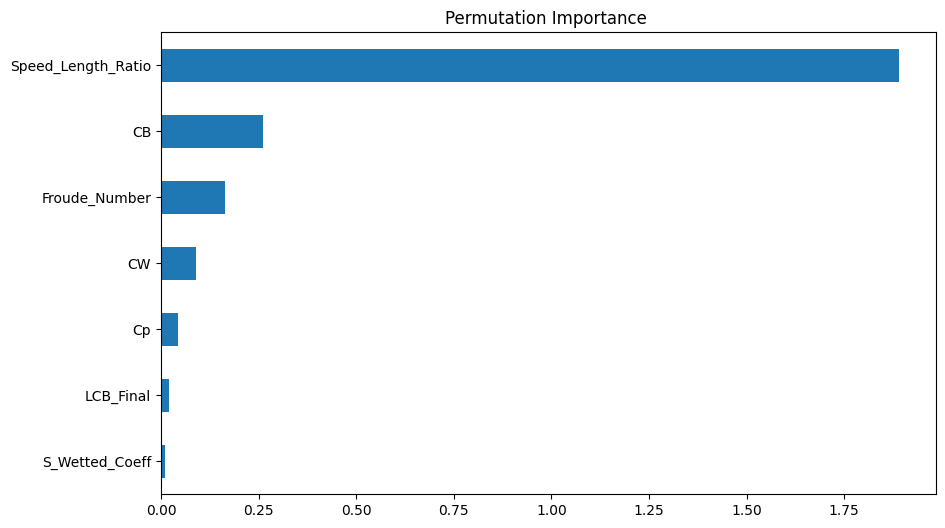

In [68]:
# حساب الأهمية بطريقة اللخبطة على داتا الـ Valid
result = permutation_importance(model, x_validation, y_validation, n_repeats=10, random_state=42)

# Reorder the features according their importance for easy comparison in the chart
sorted_importances_idx = result.importances_mean.argsort()
importances = pd.Series(result.importances_mean[sorted_importances_idx], index=x_train.columns[sorted_importances_idx])

# drawing the chart
plt.figure(figsize=(10, 6))
importances.plot(kind='barh')
plt.title("Permutation Importance ")
plt.show()

In [69]:
# Test data which contains models number 4211 and 4213
print('real test set performance')
prediction_and_evaluation(x_test, y_test, model)

real test set performance
--------------------------------------------------
 Error value (MAE): 0.01633
 Prediction efficiency (R² Score): 99.20%
--------------------------------------------------


In [70]:
print(model.best_iteration)

289
